 **Tarea: Mejorar la imagen**





Importación de la imagen junto con su escala de gris e histograma

size =  (256, 256)


Text(0, 0.5, 'Frecuencia')

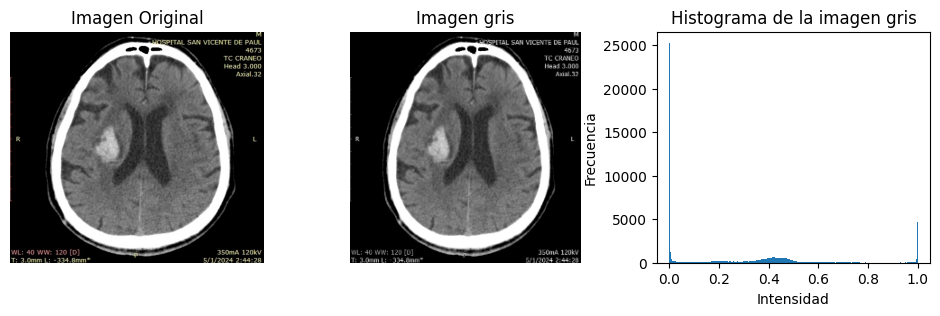

In [140]:
#Carga de la imagen
import matplotlib.pyplot as plt
import cv2
from skimage.transform import resize
import numpy as np
from skimage import color

img_original = cv2.imread('src/ima2.jpeg') #Cargar imagen original
img_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

img_grey = color.rgb2gray(img_original) #Convertir a escala de grises
img = resize(img_grey, (256, 256), anti_aliasing=True).astype(np.float32)  # tamaño 256x256, valores en [0,1]  y tipo float32

# Visualización de la imagen y su histograma
print('size = ',img.shape)

plt.figure(figsize=(12, 3))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.axis('off')
plt.title("Imagen Original")

plt.subplot(1, 3, 2)
plt.imshow(img,cmap='gray')
plt.axis('off')
plt.title("Imagen gris")

plt.subplot(1, 3, 3)
plt.hist(img.ravel(), bins=256)
plt.title("Histograma de la imagen gris")
plt.xlabel("Intensidad"); plt.ylabel("Frecuencia")


Eliminación de ruido y suavizado

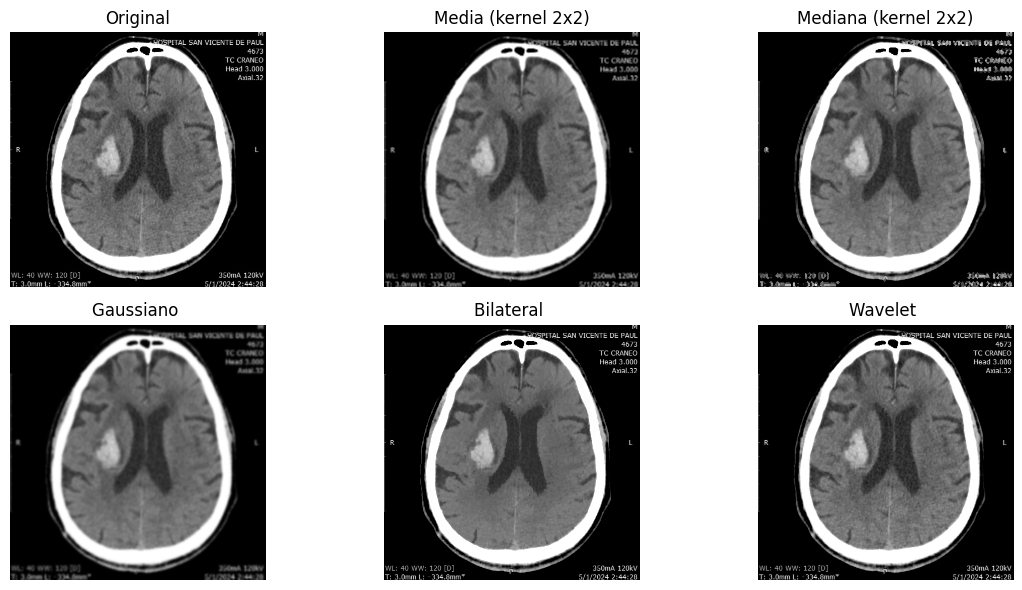

In [141]:
# Eliminación de ruido y suavizado

from scipy.ndimage import uniform_filter, median_filter
from skimage.filters import gaussian
from skimage.restoration import denoise_bilateral, denoise_wavelet


k = 2 # tamaño del kernel (k x k)
img_mean = uniform_filter(img, size=k)      #filtro de media con kernel k x k
img_median = median_filter(img, size=k)     #filtro de mediana con kernel k x k
img_gauss = gaussian(img, sigma=0.9)        # Gaussiano
img_bilat = denoise_bilateral(              # Bilateral (edge-preserving)
    img,
    sigma_color=0.03,     # sensibilidad a diferencias de intensidad
    sigma_spatial=3,      # vecindario espacial
    channel_axis=None
)
img_wave = denoise_wavelet(img,channel_axis=None, rescale_sigma=True)  # Wavelet (edge-preserving)

# 4) Visualización
plt.figure(figsize=(12, 6))
plt.subplot(2, 3, 1); plt.imshow(img, cmap="gray"); plt.title("Original");plt.axis("off")
plt.subplot(2, 3, 2); plt.imshow(img_mean, cmap="gray"); plt.title(f"Media (kernel {k}x{k})"); plt.axis("off")
plt.subplot(2, 3, 3); plt.imshow(img_median, cmap="gray"); plt.title(f"Mediana (kernel {k}x{k})"); plt.axis("off")
plt.subplot(2, 3, 4); plt.imshow(img_gauss, cmap="gray"); plt.title("Gaussiano "); plt.axis("off")
plt.subplot(2, 3, 5); plt.imshow(img_bilat, cmap="gray"); plt.title(f"Bilateral "); plt.axis("off")
plt.subplot(2, 3, 6); plt.imshow(img_wave, cmap="gray"); plt.title(f"Wavelet "); plt.axis("off")
plt.tight_layout()
plt.show()

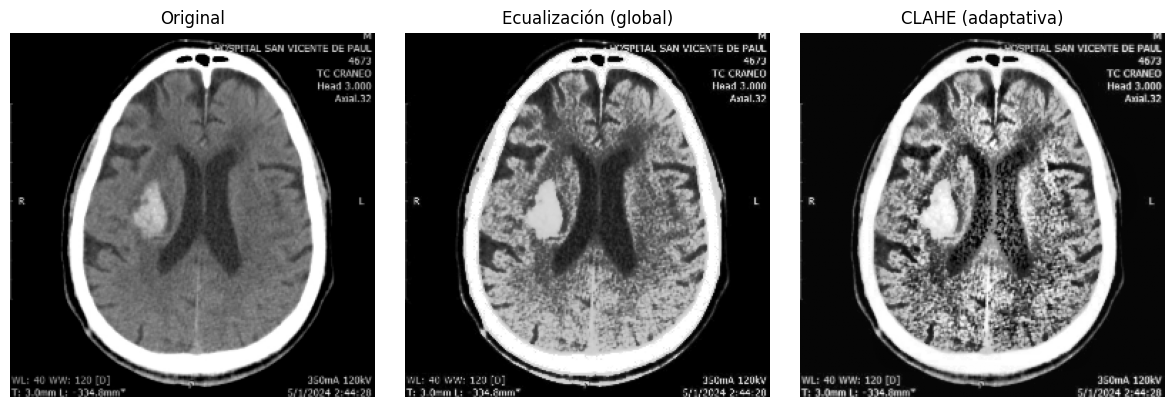

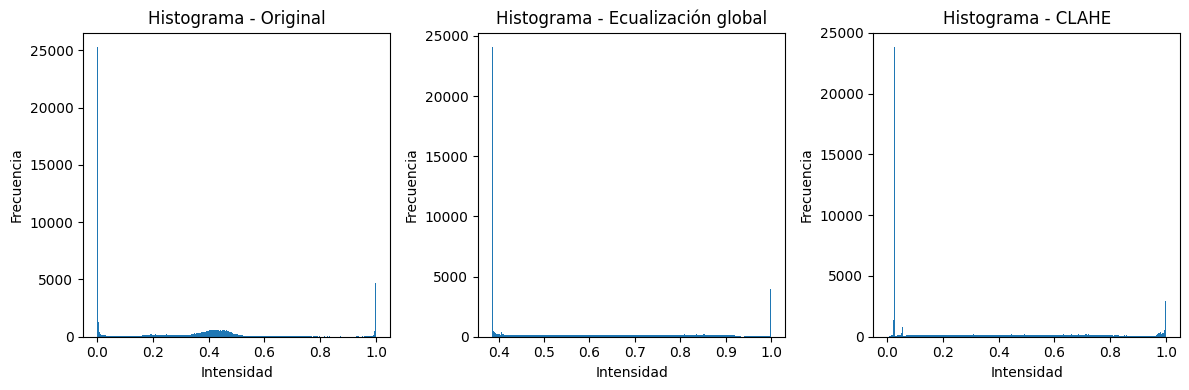

In [142]:
#Verificación de la imagen y sus ecualizaciones
from skimage import exposure

# 2) Ecualización global de histograma
img_eq = exposure.equalize_hist(img)  # salida en [0,1]

# (Opcional) CLAHE / ecualización adaptativa (más suave, suele funcionar mejor en muchos casos)
img_clahe = exposure.equalize_adapthist(img, clip_limit=0.03)

# 3) Graficar imágenes
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(img, cmap="gray"); plt.title("Original"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(img_eq, cmap="gray"); plt.title("Ecualización (global)"); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(img_clahe, cmap="gray"); plt.title("CLAHE (adaptativa)"); plt.axis("off")
plt.tight_layout()
plt.show()

# 4) Graficar histogramas
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.hist(img.ravel(), bins=256);plt.title("Histograma - Original");plt.xlabel("Intensidad"); plt.ylabel("Frecuencia")
plt.subplot(1, 3, 2);plt.hist(img_eq.ravel(), bins=256);plt.title("Histograma - Ecualización global");plt.xlabel("Intensidad"); plt.ylabel("Frecuencia")
plt.subplot(1, 3, 3);plt.hist(img_clahe.ravel(), bins=256);plt.title("Histograma - CLAHE");plt.xlabel("Intensidad"); plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


Muestreo

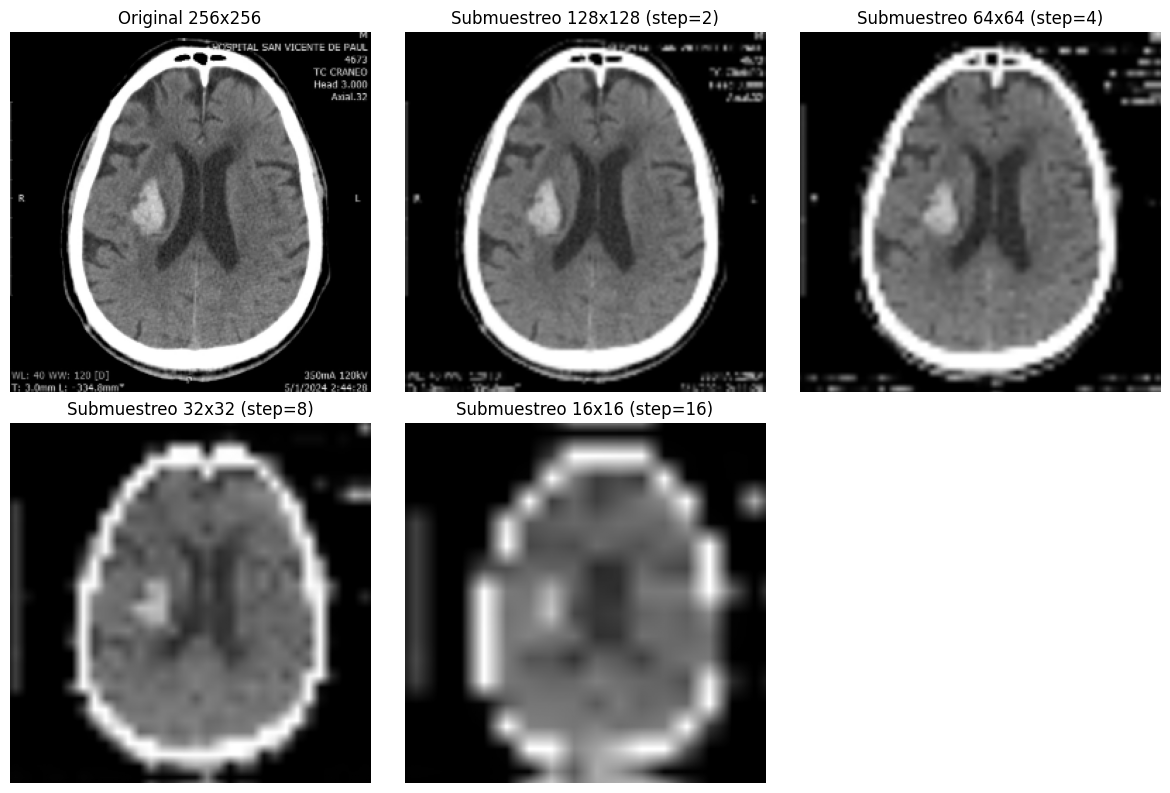

128 (128, 128)
64 (64, 64)
32 (32, 32)
16 (16, 16)


In [143]:
#Submuestreo
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color
from skimage.transform import resize

def subsample_every_k(img, k):
    """
    Submuestreo por 'tomar un píxel sí y (k-1) no' en filas y columnas.
    k=2 -> 128x128 (1 sí, 1 no)
    k=4 -> 64x64
    k=8 -> 32x32
    k=16 -> 16x16
    """
    return img[::k, ::k]

# Submuestreos solicitados (desde 256x256)
factors = {128: 2, 64: 4, 32: 8, 16: 16}
samples = {}
ups = {}

for size, k in factors.items():
    low = subsample_every_k(img, k)  # toma un píxel sí y k-1 no
    samples[size] = low
    # Volver a 256x256 solo para visualizar el efecto "pixelado"
    ups[size] = resize(low, (256, 256), anti_aliasing=False)

# Mostrar resultados
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original 256x256")
plt.axis("off")

for i, size in enumerate([128, 64, 32, 16], start=2):
    plt.subplot(2, 3, i)
    plt.imshow(ups[size], cmap="gray")
    k = factors[size]
    plt.title(f"Submuestreo {size}x{size} (step={k})")
    plt.axis("off")

plt.tight_layout()
plt.show()

# (Opcional) Ver tamaños reales submuestreados
for size in [128, 64, 32, 16]:
    print(size, samples[size].shape)

#Conclusiones: Con 128x128 se mantiene una buena calidad para el análisis

Cuantización

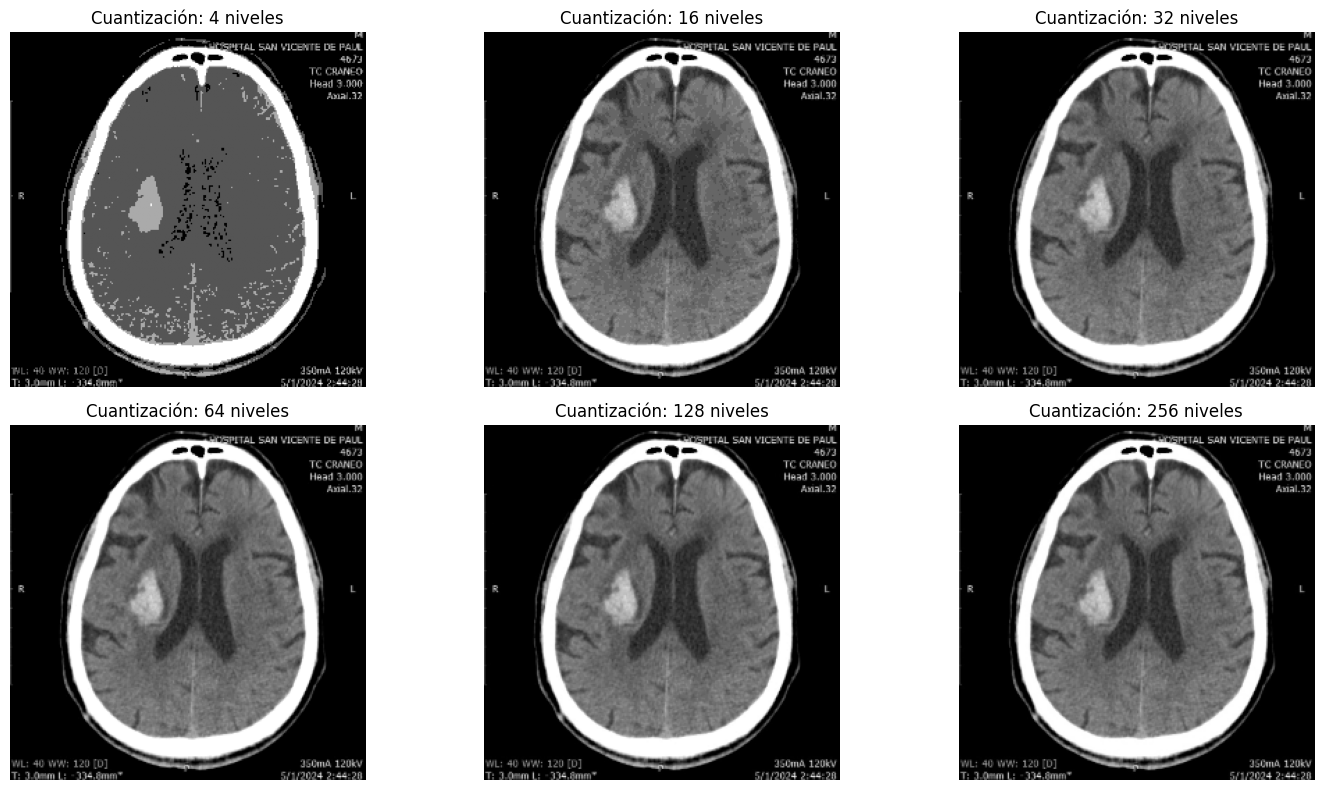

In [144]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color
from skimage.transform import resize

# Imagen base (gris, 256x256)
img_128 = img[::1, ::1]


# -----------------------------
# 2) CUANTIZACIÓN DE INTENSIDAD (niveles de gris)
# -----------------------------
# Idea: mantener la misma resolución, pero reducir el número de niveles (bits).
def quantize_levels(x, levels):
    # x en [0,1]
    xq = np.round(x * (levels - 1)) / (levels - 1)
    return xq

# Niveles típicos: 2 (1 bit), 4 (2 bits), 16 (4 bits), 256 (8 bits)
levels_list = [4,16,32,64,128,256]
quantized = {L: quantize_levels(img_128, L) for L in levels_list}

plt.figure(figsize=(15, 8)) # Ajustado el figsize para 6 imágenes
for i, L in enumerate(levels_list, start=1):
    plt.subplot(2, 3, i) # Cambiado a 2 filas, 3 columnas
    plt.imshow(quantized[L], cmap="gray", vmin=0, vmax=1)
    plt.title(f"Cuantización: {L} niveles")
    plt.axis("off")

plt.tight_layout()
plt.show()

#Con 16 niveles sobre la imagen de 120 *128 se mantiene una buena imagen para segmentar mancha del centro del craneo

Segmentación


Imagen procesada: Original
Objetos (4-conectividad): 162
Objetos (8-conectividad): 144


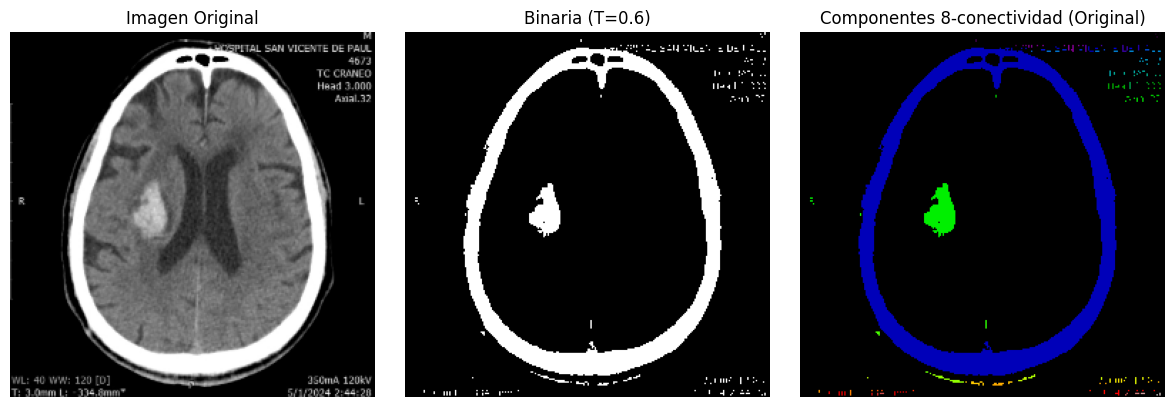


Imagen procesada: Media
Objetos (4-conectividad): 23
Objetos (8-conectividad): 22


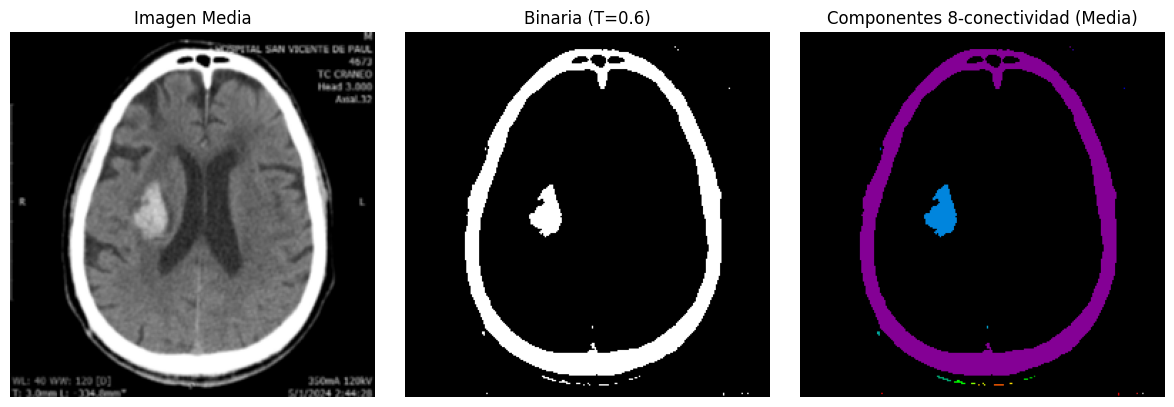


Imagen procesada: Mediana
Objetos (4-conectividad): 73
Objetos (8-conectividad): 73


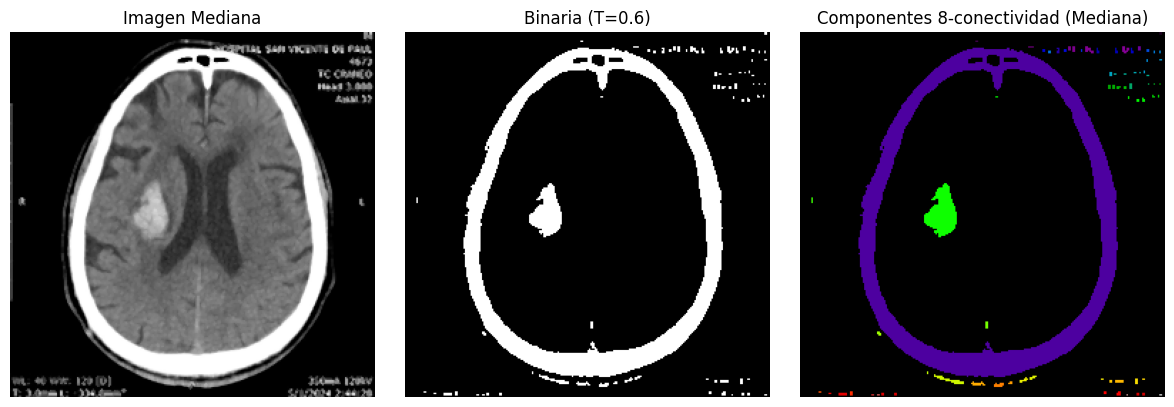


Imagen procesada: Gaussiana
Objetos (4-conectividad): 4
Objetos (8-conectividad): 3


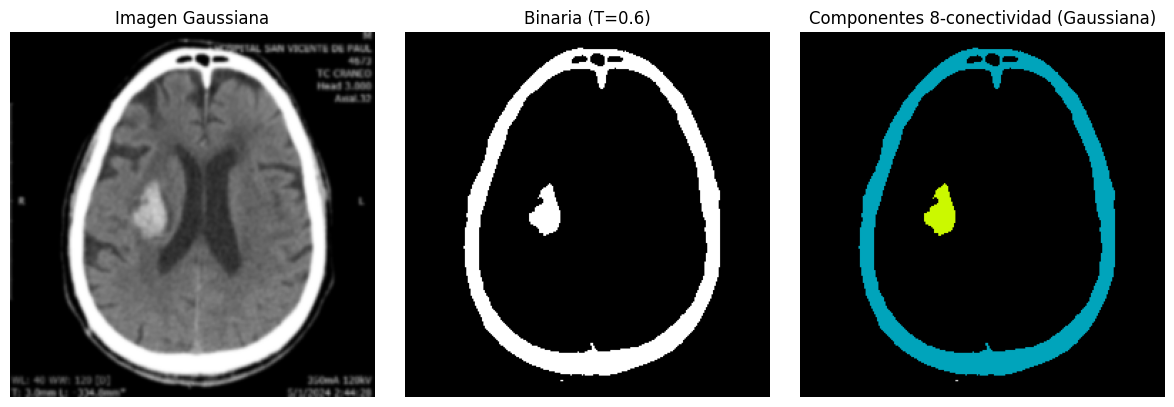


Imagen procesada: Bilateral
Objetos (4-conectividad): 162
Objetos (8-conectividad): 142


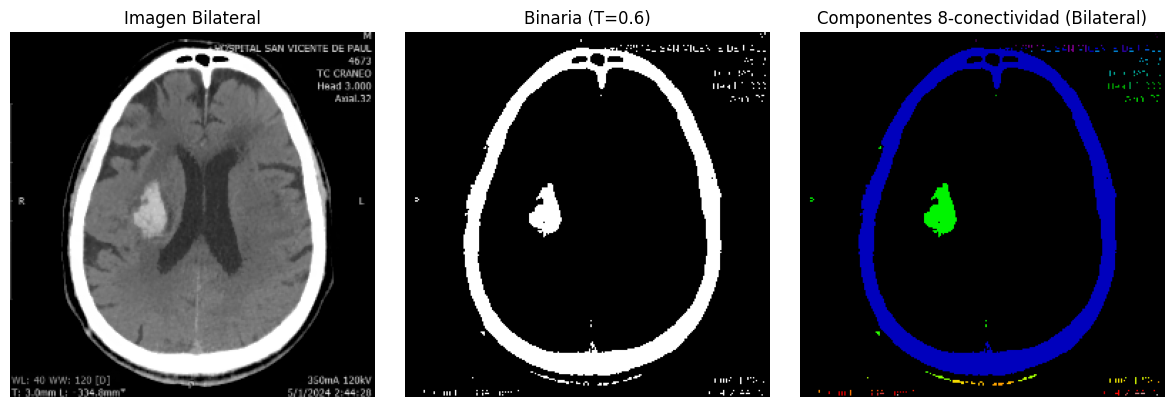


Imagen procesada: Wavelet
Objetos (4-conectividad): 160
Objetos (8-conectividad): 142


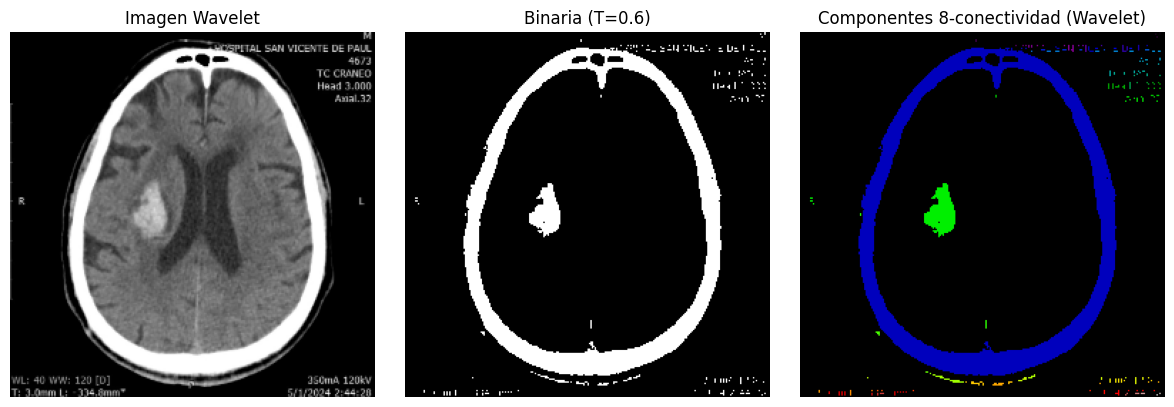

In [146]:
from skimage.measure import label
from skimage.transform import resize

# Diccionario de imágenes a probar
imagenes = {
    "Original": img,
    "Media": img_mean,
    "Mediana": img_median,
    "Gaussiana": img_gauss,
    "Bilateral": img_bilat,
    "Wavelet": img_wave
}

T = 0.60  # umbral

for nombre, img_in in imagenes.items():
    # Imagen seleccionada
    img_proc = resize(img_in, (256, 256), anti_aliasing=True).astype(np.float32)

    # Binarización
    bw = (img_proc > T).astype(np.uint8)

    # Etiquetado
    L4_img = label(bw, connectivity=1)
    L8_img = label(bw, connectivity=2)

    print(f"\nImagen procesada: {nombre}")
    print("Objetos (4-conectividad):", int(L4_img.max()))
    print("Objetos (8-conectividad):", int(L8_img.max()))

    # Visualización
    plt.figure(figsize=(12,4)); plt.subplot(1,3,1); plt.imshow(img_proc, cmap="gray"); plt.title(f"Imagen {nombre}"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(bw, cmap="gray"); plt.title(f"Binaria (T={T})"); plt.axis("off")
    plt.subplot(1,3,3);plt.imshow(L8_img, cmap="nipy_spectral"); plt.title(f"Componentes 8-conectividad ({nombre})"); plt.axis("off")
    plt.tight_layout()
    plt.show()
